# Research & Innovation Capacity — Full Sub-Indicator Extraction and Income-Adjustment Test

**Source:** WIPO GII 2025, `wipo-pub-2000-2025-gii-tech1.xlsx`, plus World Bank GDP 
(PPP) already used in prior notebooks.

**Purpose:** The earlier test only checked two pillar-level scores (Human Capital 
& Research, Knowledge & Tech Outputs). This extracts all 32 indicator-level 
components underneath — including researchers per capita, R&D spending, 
university-industry collaboration, patent families, and citable documents 
H-index — and runs the income-adjustment test on each individually. Goal: find 
out if any specific sub-indicator shows a real Nepal-specific anomaly the way 
Government Digital Policy did, even though the broad pillars came back 
income-typical.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../outputs/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

GII_FILE = RAW_DIR / "wipo-pub-2000-2025-gii-tech1.xlsx"
GDP_FILE = next(RAW_DIR.glob("API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))
GDP_META_FILE = next(RAW_DIR.glob("Metadata_Country_API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#333333", "axes.grid": True, "grid.alpha": 0.25,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
sns.set_style("whitegrid")
NEPAL = "Nepal"

## 1. Identify all sub-indicators under the three relevant pillars

Human Capital & Research (IN.2), Business Sophistication (IN.5 — this is where 
university-industry collaboration actually lives, not IN.2), and Knowledge & 
Tech Outputs (OUT.6).

In [2]:
struct = pd.read_excel(GII_FILE, sheet_name="Index Structure")
data = pd.read_excel(GII_FILE, sheet_name="Data")
econ = pd.read_excel(GII_FILE, sheet_name="Economies")

PILLAR_PREFIXES = ["IN.2", "IN.5", "OUT.6"]
indicators = struct[
    (struct.LEVEL == "Indicator") &
    (struct.NUM.apply(lambda x: any(str(x).startswith(p) for p in PILLAR_PREFIXES)))
][["NUM", "NAME"]].reset_index(drop=True)

print(f"Found {len(indicators)} indicators across {PILLAR_PREFIXES}")
indicators

Found 41 indicators across ['IN.2', 'IN.5', 'OUT.6']


,NUM,NAME
0,IN.2.1.1,"Expenditure on education, % GDP"
1,IN.2.1.2,"Government funding/pupil, secondary, % GDP/cap"
2,IN.2.1.3,"School life expectancy, years"
3,IN.2.1.4,"PISA scales in reading, maths and science"
4,IN.2.1.5,"Pupil–teacher ratio, secondary"
5,IN.2.2.1,"Tertiary enrolment, % gross"
6,IN.2.2.2,"Graduates in science and engineering, %"
7,IN.2.2.3,"Tertiary inbound mobility, %"
8,IN.2.3.1,"Researchers, FTE/mn pop."
9,IN.2.3.2,"Gross expenditure on R&D, % GDP"


## 2. Nepal's actual value and global rank on every one of these indicators

In [3]:
rows = []
for _, ind in indicators.iterrows():
    code, name = ind["NUM"], ind["NAME"]
    ind_data = data[data.NUM == code][["ECONOMY_NAME", "SCORE", "RANK"]].dropna(subset=["SCORE"])
    nepal_row = ind_data[ind_data.ECONOMY_NAME == NEPAL]
    if len(nepal_row) == 0:
        rows.append({"Code": code, "Indicator": name, "Nepal_Score": np.nan, "Nepal_Rank": np.nan, "N_countries": len(ind_data)})
        continue
    rows.append({
        "Code": code, "Indicator": name,
        "Nepal_Score": nepal_row.SCORE.iloc[0],
        "Nepal_Rank": int(nepal_row.RANK.iloc[0]),
        "N_countries": len(ind_data),
    })

nepal_full_scorecard = pd.DataFrame(rows).sort_values("Nepal_Rank", ascending=False)
nepal_full_scorecard.to_csv(PROCESSED_DIR / "nepal_research_innovation_full_scorecard.csv", index=False)
with open(PROCESSED_DIR / "nepal_research_innovation_full_scorecard.md", "w") as f:
    f.write(nepal_full_scorecard.to_markdown(index=False))
nepal_full_scorecard

,Code,Indicator,Nepal_Score,Nepal_Rank,N_countries
24,IN.5.3.3,"ICT services imports, % total trade",2.247908,136.0,139
38,OUT.6.3.3,"High-tech exports, % total trade",0.042137,136.0,138
22,IN.5.3.1,"Intellectual property payments, % total trade",0.006175,130.0,139
34,OUT.6.2.3,"Software spending, % GDP",1.140350,130.0,138
4,IN.2.1.5,"Pupil–teacher ratio, secondary",30.326088,126.0,131
25,IN.5.3.4,"FDI net inflows, % GDP",37.945503,124.0,138
20,IN.5.2.4,State of cluster development†,25.098098,117.0,135
5,IN.2.2.1,"Tertiary enrolment, % gross",9.958448,105.0,133
18,IN.5.2.2,University–industry R&D collaboration†,22.878978,105.0,134
13,IN.5.1.2,"Females employed w/advanced degrees, %",9.011772,102.0,125


## 3. Income-adjustment test on every indicator, not just the pillar aggregates

Same method as before (regress score on log GDP per capita, take Nepal's 
residual and percentile) — run in a loop across all 32 indicators this time.

In [4]:
wb = pd.read_csv(GDP_FILE, skiprows=4)
wb_meta = pd.read_csv(GDP_META_FILE)
real_codes = set(wb_meta.loc[wb_meta["Region"].notna(), "Country Code"])
wb = wb[wb["Country Code"].isin(real_codes)]
year_cols = [c for c in wb.columns if c.isdigit()]

def latest_value(row):
    for y in sorted(year_cols, reverse=True):
        if pd.notna(row[y]):
            return row[y]
    return np.nan

wb["gdp"] = wb.apply(latest_value, axis=1)
wb_clean = wb[["Country Code", "gdp"]].dropna()

# GII already has ISO3 — merge directly, no name-matching needed
econ_gdp = econ.merge(wb_clean, left_on="ISO3", right_on="Country Code", how="left")
econ_gdp["log_gdp"] = np.log(econ_gdp["gdp"])

results = []
for _, ind in indicators.iterrows():
    code, name = ind["NUM"], ind["NAME"]
    ind_data = data[data.NUM == code][["ISO3", "SCORE"]].dropna()
    merged = ind_data.merge(econ_gdp[["ISO3", "ECONOMY_NAME", "log_gdp"]], on="ISO3", how="left").dropna(subset=["log_gdp"])

    if len(merged) < 20 or merged.SCORE.std() == 0:
        continue

    slope, intercept, r, p, se = stats.linregress(merged["log_gdp"], merged["SCORE"])
    merged["resid"] = merged["SCORE"] - (slope * merged["log_gdp"] + intercept)

    nepal_resid_row = merged[merged.ECONOMY_NAME == NEPAL]
    if len(nepal_resid_row) == 0:
        continue
    nepal_resid = nepal_resid_row["resid"].iloc[0]
    pct = stats.percentileofscore(merged["resid"], nepal_resid)

    results.append({
        "Code": code, "Indicator": name, "n": len(merged),
        "income_corr_r": r, "income_corr_p": p,
        "Nepal_residual": nepal_resid, "Nepal_percentile": pct,
    })

income_test_results = pd.DataFrame(results).sort_values("Nepal_percentile")
income_test_results.to_csv(PROCESSED_DIR / "research_innovation_income_adjusted_all_indicators.csv", index=False)
with open(PROCESSED_DIR / "research_innovation_income_adjusted_all_indicators.md", "w") as f:
    f.write(income_test_results.to_markdown(index=False))

print("Worst 8 income-adjusted percentiles (real potential anomalies):")
print(income_test_results.head(8).to_string(index=False))
print("\nBest 5 (Nepal outperforming income prediction):")
print(income_test_results.tail(5).to_string(index=False))

Worst 8 income-adjusted percentiles (real potential anomalies):
     Code                                      Indicator   n  income_corr_r  income_corr_p  Nepal_residual  Nepal_percentile
 IN.2.1.5                 Pupil–teacher ratio, secondary 131       0.687330   1.237338e-19      -28.291020          4.580153
 IN.5.3.4                         FDI net inflows, % GDP 138      -0.007466   9.307419e-01       -9.521940         10.869565
 IN.2.1.2 Government funding/pupil, secondary, % GDP/cap  94       0.238724   2.049546e-02      -16.273541         15.957447
 IN.5.3.3            ICT services imports, % total trade 139       0.274819   1.060049e-03      -12.940765         17.985612
 IN.5.1.3                  Youth demographic dividend, % 139      -0.881455   1.780132e-46      -11.319644         19.424460
 IN.5.3.1  Intellectual property payments, % total trade 139       0.412963   4.368795e-07       -8.352063         23.021583
 IN.5.2.4                  State of cluster development† 135 

## 4. Figure — dot plot of every indicator's income-adjusted percentile

One row per indicator, dot position = Nepal's percentile. Left of the 50-line 
means Nepal underperforms its income prediction; right means it outperforms. 
A new chart type for this project — not a repeat of the bar/heatmap/radar/scatter 
patterns already used.

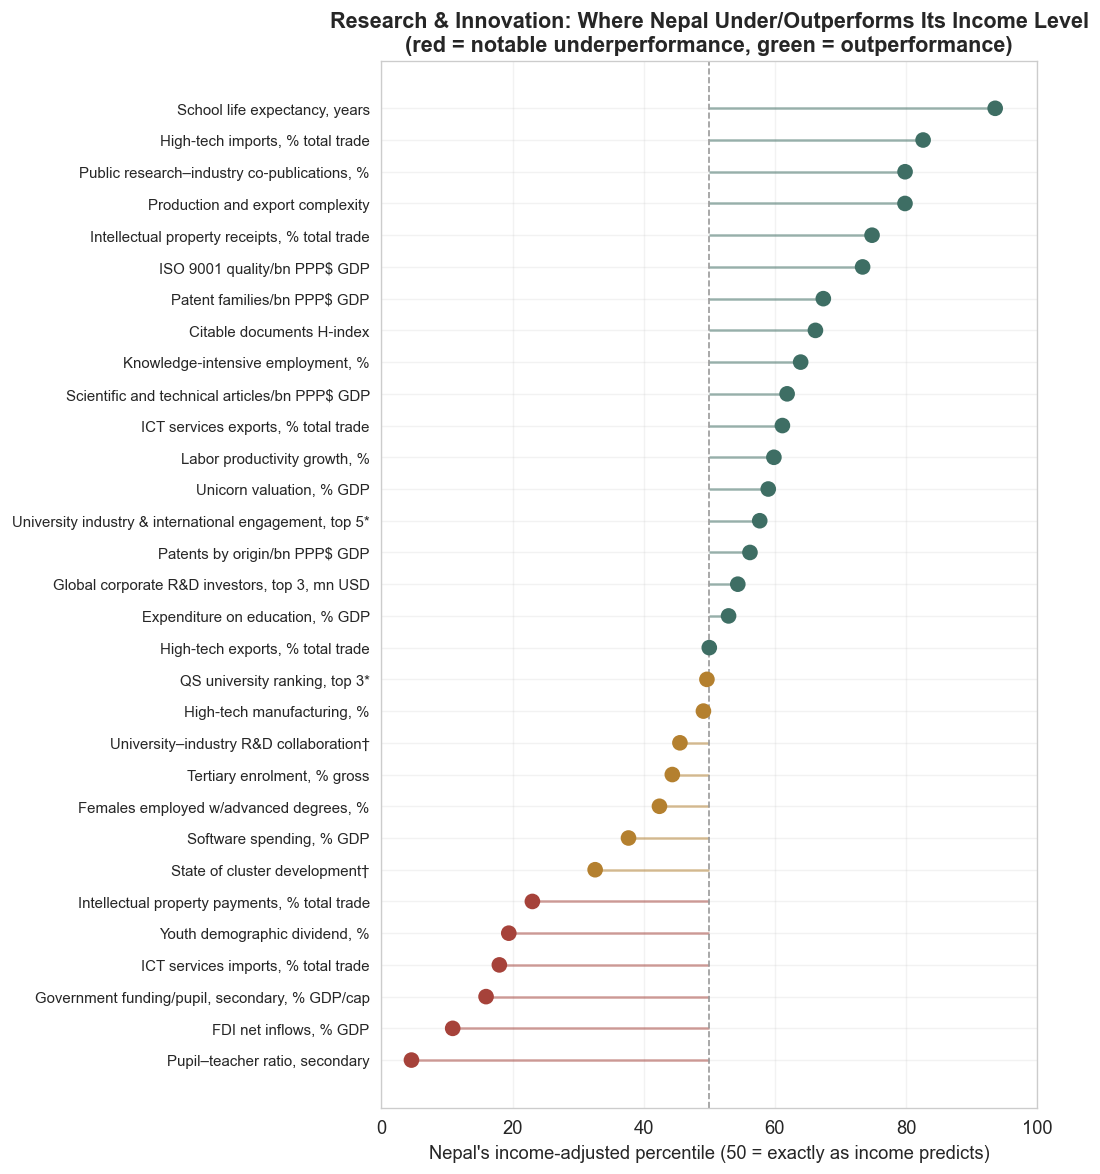

In [5]:
plot_df = income_test_results.sort_values("Nepal_percentile").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, max(6, 0.32 * len(plot_df))))
colors = ["#A6423A" if p < 25 else ("#B4802F" if p < 50 else "#3E6E64") for p in plot_df["Nepal_percentile"]]

ax.hlines(y=plot_df.index, xmin=50, xmax=plot_df["Nepal_percentile"], color=colors, alpha=0.5, linewidth=1.5)
ax.scatter(plot_df["Nepal_percentile"], plot_df.index, color=colors, s=70, zorder=3)
ax.axvline(50, color="#999999", linestyle="--", linewidth=1)

ax.set_yticks(plot_df.index)
ax.set_yticklabels(plot_df["Indicator"], fontsize=9)
ax.set_xlabel("Nepal's income-adjusted percentile (50 = exactly as income predicts)")
ax.set_xlim(0, 100)
ax.set_title("Research & Innovation: Where Nepal Under/Outperforms Its Income Level\n(red = notable underperformance, green = outperformance)")
fig.tight_layout()
fig.savefig(FIG_DIR / "research_innovation_income_adjusted_dotplot.png", bbox_inches="tight")
plt.show()

In [6]:
for code in ["IN.2.3.1", "IN.2.3.2"]:
    row = income_test_results[income_test_results.Code == code]
    print(row.to_string(index=False) if len(row) else f"{code}: not in results — check if it survived the n>=20 / std>0 filter")

IN.2.3.1: not in results — check if it survived the n>=20 / std>0 filter
IN.2.3.2: not in results — check if it survived the n>=20 / std>0 filter
